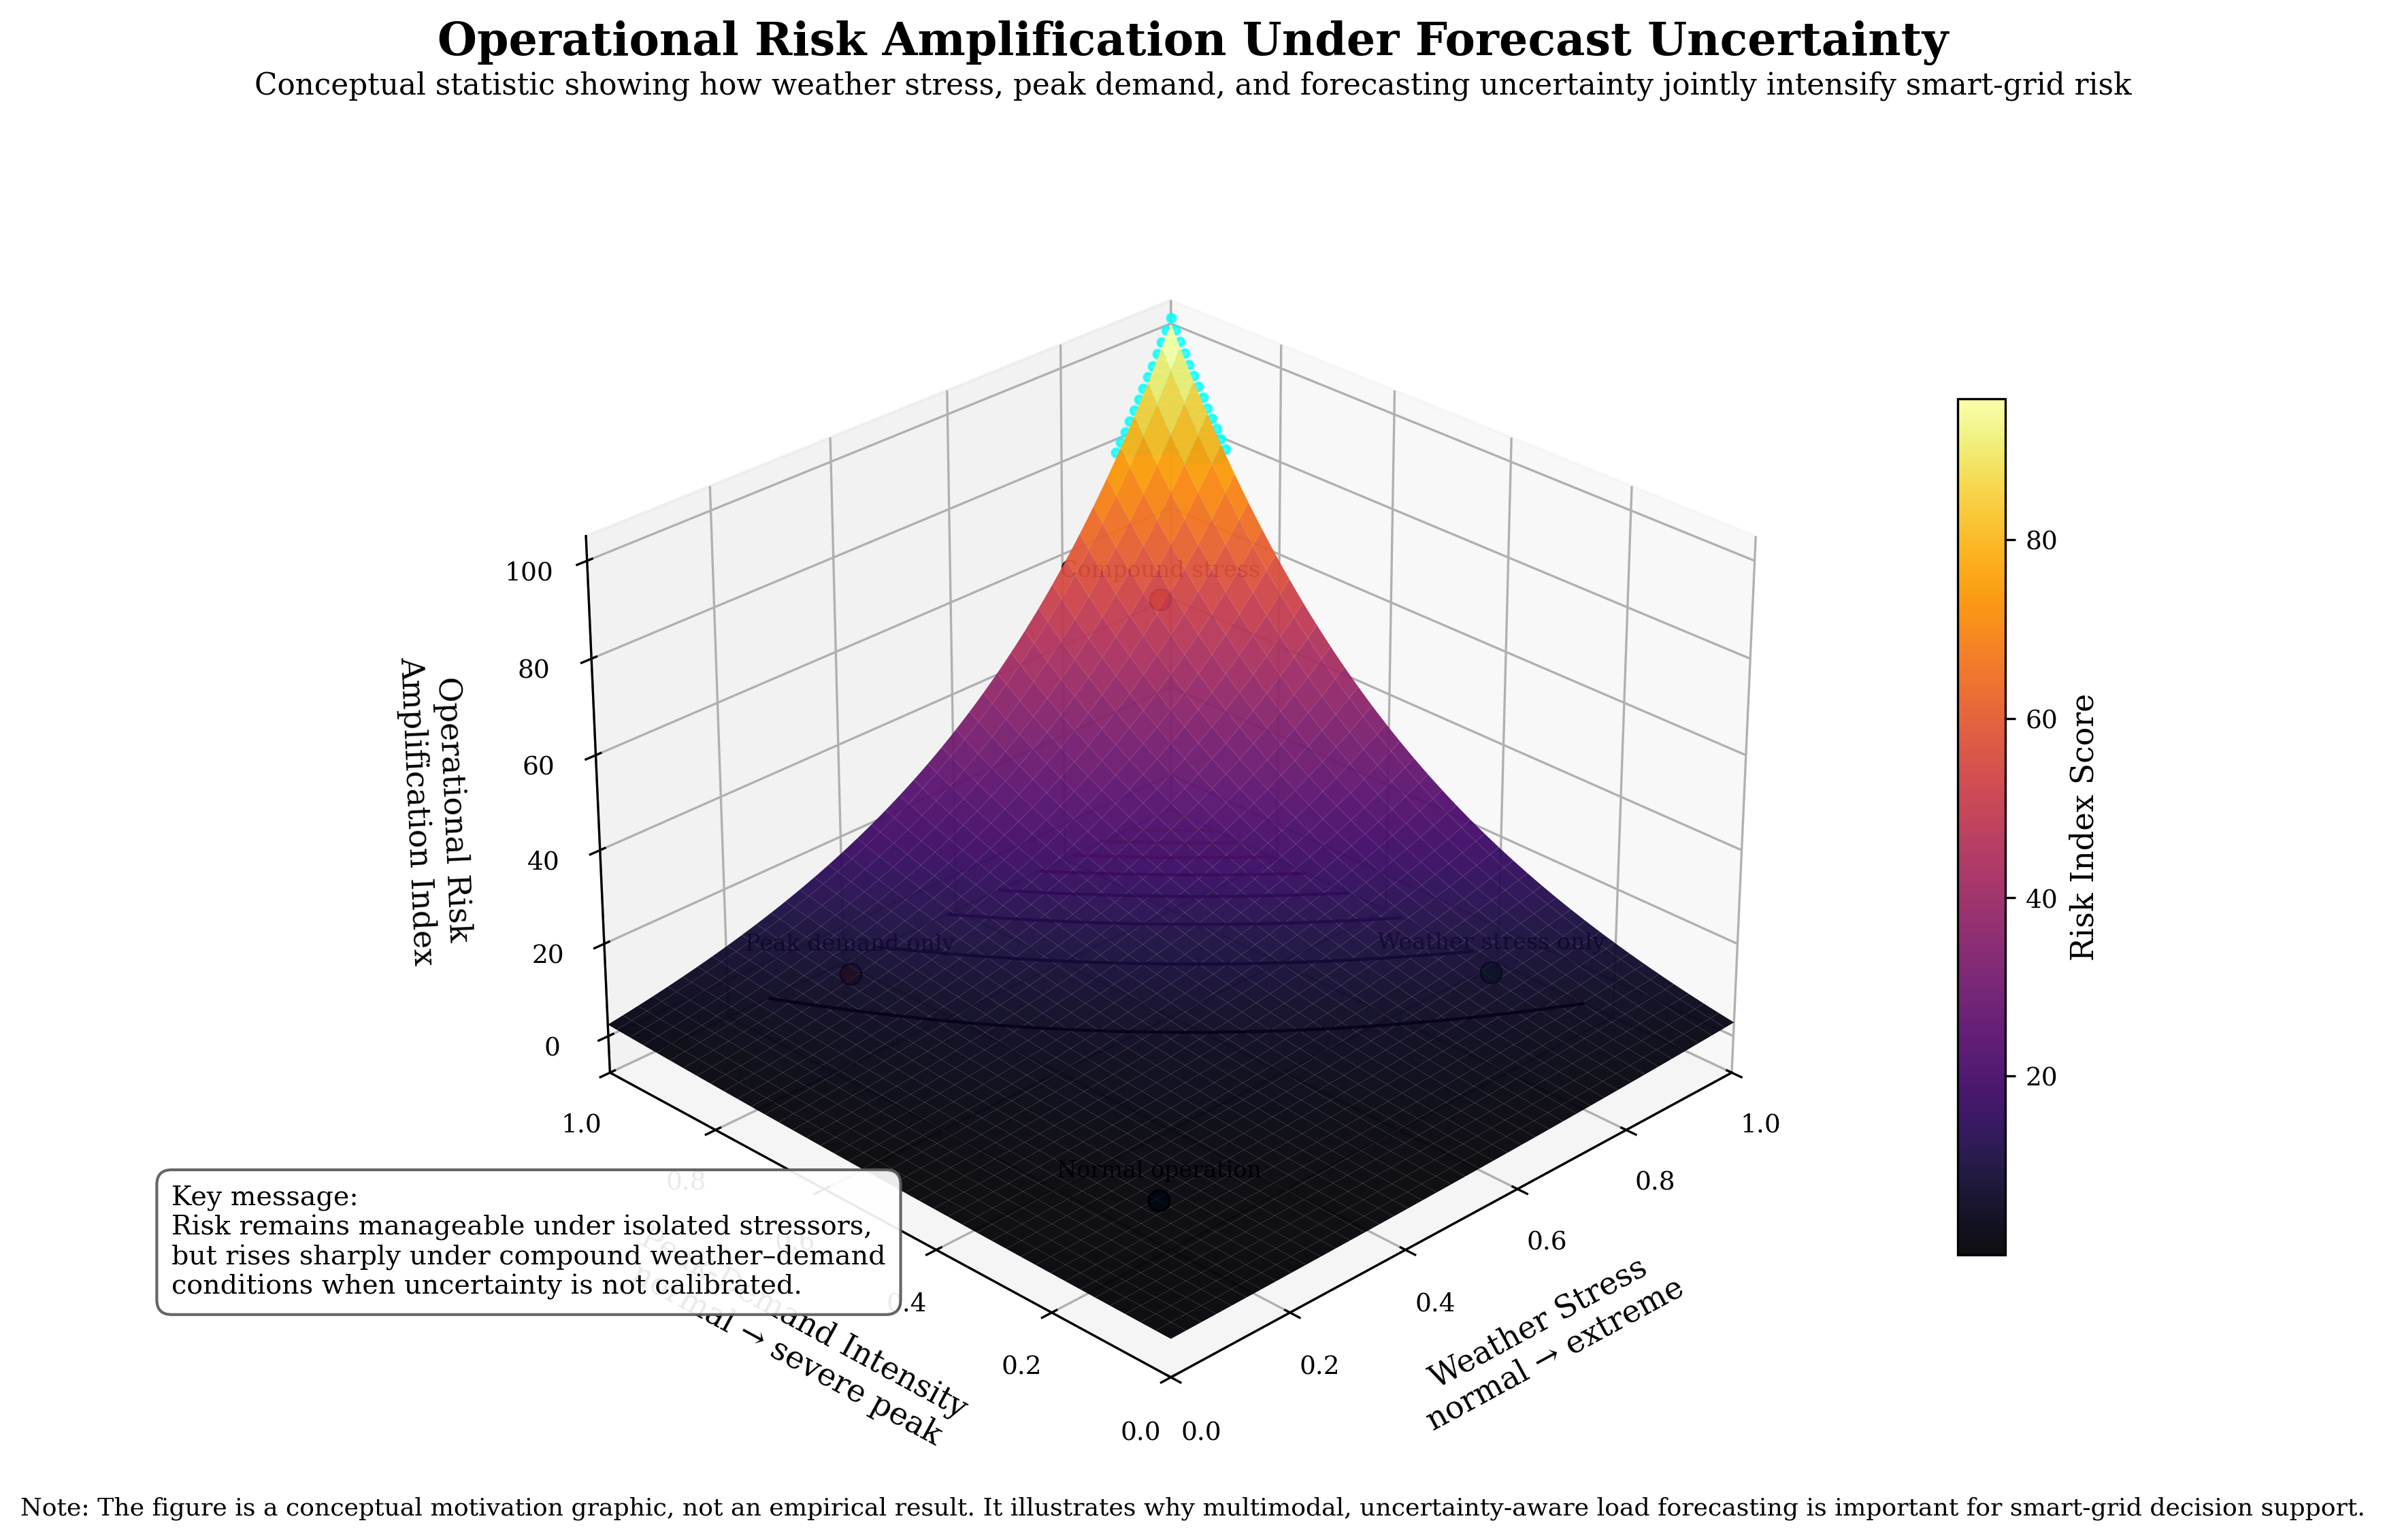

Saved publication-ready PDF figure as: intro_operational_risk_amplification.pdf


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MaxNLocator

# ============================================================
# Publication-ready conceptual introductory figure
# No dataset dependency
# ============================================================

# Output file
OUTPUT_FILE = "intro_operational_risk_amplification.pdf"

# Reproducibility for any minor jitter/annotation choices
np.random.seed(42)

# ------------------------------------------------------------
# Conceptual axes
# ------------------------------------------------------------
# Weather stress:
# 0 = normal weather, 1 = extreme temperature stress
weather_stress = np.linspace(0, 1, 120)

# Peak-demand intensity:
# 0 = normal demand, 1 = severe peak-load condition
peak_intensity = np.linspace(0, 1, 120)

W, P = np.meshgrid(weather_stress, peak_intensity)

# ------------------------------------------------------------
# Conceptual uncertainty function
# ------------------------------------------------------------
# Forecast uncertainty rises when both weather stress and peak demand increase.
# This reflects the idea that rare combined conditions are harder to forecast.
forecast_uncertainty = (
    0.15
    + 0.40 * W**1.6
    + 0.35 * P**1.4
    + 0.60 * (W * P)**1.8
)

# ------------------------------------------------------------
# Proposed statistic:
# Operational Risk Amplification Index
# ------------------------------------------------------------
# Risk increases multiplicatively with weather stress, peak-demand intensity,
# and forecast uncertainty.
risk_index = (
    (0.20 + W)**1.4
    * (0.25 + P)**1.5
    * (1.0 + forecast_uncertainty)**2.2
)

# Normalize to 0–100 for interpretability
risk_index = 100 * (risk_index - risk_index.min()) / (risk_index.max() - risk_index.min())

# ------------------------------------------------------------
# Figure styling
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 14,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

fig = plt.figure(figsize=(11.5, 8.0))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 3D surface
# ------------------------------------------------------------
surface = ax.plot_surface(
    W,
    P,
    risk_index,
    cmap=cm.inferno,
    linewidth=0,
    antialiased=True,
    alpha=0.94
)

# ------------------------------------------------------------
# Contour projection at the bottom
# ------------------------------------------------------------
z_offset = -8

contours = ax.contour(
    W,
    P,
    risk_index,
    zdir="z",
    offset=z_offset,
    levels=np.linspace(10, 90, 9),
    cmap=cm.inferno,
    linewidths=1.1
)

# ------------------------------------------------------------
# Highlight critical operating region
# ------------------------------------------------------------
critical_mask = risk_index > 75

critical_x = W[critical_mask]
critical_y = P[critical_mask]
critical_z = risk_index[critical_mask]

# Plot sparse critical points for readability
if len(critical_x) > 0:
    idx = np.linspace(0, len(critical_x) - 1, min(180, len(critical_x))).astype(int)
    ax.scatter(
        critical_x[idx],
        critical_y[idx],
        critical_z[idx] + 1.2,
        s=8,
        c="cyan",
        alpha=0.75,
        depthshade=False,
        label="Critical risk region"
    )

# ------------------------------------------------------------
# Example operating points
# ------------------------------------------------------------
operating_points = {
    "Normal operation": (0.18, 0.20),
    "Peak demand only": (0.25, 0.82),
    "Weather stress only": (0.82, 0.25),
    "Compound stress": (0.86, 0.88)
}

for label, (wx, py) in operating_points.items():
    fu = (
        0.15
        + 0.40 * wx**1.6
        + 0.35 * py**1.4
        + 0.60 * (wx * py)**1.8
    )
    rz = (
        (0.20 + wx)**1.4
        * (0.25 + py)**1.5
        * (1.0 + fu)**2.2
    )

    # Convert to normalized scale using original min/max
    raw_grid = (
        (0.20 + W)**1.4
        * (0.25 + P)**1.5
        * (1.0 + forecast_uncertainty)**2.2
    )
    rz_norm = 100 * (rz - raw_grid.min()) / (raw_grid.max() - raw_grid.min())

    ax.scatter(
        wx,
        py,
        rz_norm + 3,
        s=55,
        edgecolor="black",
        linewidth=0.7,
        depthshade=False
    )

    ax.text(
        wx,
        py,
        rz_norm + 7,
        label,
        fontsize=8,
        ha="center",
        va="bottom"
    )

# ------------------------------------------------------------
# Axes labels
# ------------------------------------------------------------
ax.set_xlabel("Weather Stress\nnormal → extreme", labelpad=12)
ax.set_ylabel("Peak-Demand Intensity\nnormal → severe peak", labelpad=12)
ax.set_zlabel("Operational Risk\nAmplification Index", labelpad=12)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(z_offset, 105)

ax.xaxis.set_major_locator(MaxNLocator(5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.zaxis.set_major_locator(MaxNLocator(6))

# View angle chosen for journal-style readability
ax.view_init(elev=28, azim=-135)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(
    surface,
    ax=ax,
    shrink=0.68,
    pad=0.08,
    aspect=18
)
cbar.set_label("Risk Index Score")
cbar.ax.tick_params(labelsize=9)

# ------------------------------------------------------------
# Main title and subtitle
# ------------------------------------------------------------
fig.suptitle(
    "Operational Risk Amplification Under Forecast Uncertainty",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.915,
    "Conceptual statistic showing how weather stress, peak demand, and forecasting uncertainty jointly intensify smart-grid risk",
    ha="center",
    fontsize=10.5
)

# ------------------------------------------------------------
# Explanatory annotation box
# ------------------------------------------------------------
annotation_text = (
    "Key message:\n"
    "Risk remains manageable under isolated stressors,\n"
    "but rises sharply under compound weather–demand\n"
    "conditions when uncertainty is not calibrated."
)

fig.text(
    0.065,
    0.18,
    annotation_text,
    fontsize=9.5,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor="0.35",
        alpha=0.92
    )
)

# ------------------------------------------------------------
# Footer note
# ------------------------------------------------------------
fig.text(
    0.5,
    0.045,
    "Note: The figure is a conceptual motivation graphic, not an empirical result. "
    "It illustrates why multimodal, uncertainty-aware load forecasting is important for smart-grid decision support.",
    ha="center",
    fontsize=8.7
)

# ------------------------------------------------------------
# Clean layout and save
# ------------------------------------------------------------
plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.92])

plt.savefig(
    OUTPUT_FILE,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print(f"Saved publication-ready PDF figure as: {OUTPUT_FILE}")